# Week 1 Local Build

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# 1. Connection setup -- pointing at Jamie's dbt models
GCP_PROJECT_ID = "ds6-module-2-olist-analytics"
DATASET_NAME = "olist_dbt_dev"
engine = create_engine(f"bigquery://{GCP_PROJECT_ID}/{DATASET_NAME}")

# 2. fct_order_items has category_name_english + price, but no order_status
#    (confirmed via BigQuery schema) -- that lives on fct_orders. Joining
#    and filtering to delivered orders, Jan 2017-Aug 2018, so this lines up
#    with the scope of category_performance_monthly used below.
pareto_query = """
    SELECT
        i.category_name_english AS category_name,
        SUM(i.price) AS total_revenue,
        COUNT(DISTINCT i.order_id) AS total_orders
    FROM fct_order_items i
    JOIN fct_orders o
        ON i.order_id = o.order_id
    WHERE o.order_status = 'delivered'
        AND o.order_purchase_ts BETWEEN '2017-01-01' AND '2018-08-31'
    GROUP BY 1
    ORDER BY total_revenue DESC
"""

# Load into Pandas
df_category = pd.read_sql(pareto_query, con=engine)

# 3. Perform 80/20 Pareto Calculation
df_category['cumulative_revenue'] = df_category['total_revenue'].cumsum()
total_revenue = df_category['total_revenue'].sum()
df_category['cumulative_percentage'] = (df_category['cumulative_revenue'] / total_revenue) * 100

# Classify categories for Inventory Strategy
def assign_tier(pct):
    if pct <= 80:
        return 'Tier A: Stock Heavily (Top 80% Revenue)'
    elif pct <= 95:
        return 'Tier B: Maintain Standard Stock (Next 15%)'
    else:
        return 'Tier C: Discount / Discontinue (Bottom 5%)'

df_category['inventory_action'] = df_category['cumulative_percentage'].apply(assign_tier)

print("--- Category Revenue Summary ---")
print(df_category[['category_name', 'total_revenue', 'cumulative_percentage', 'inventory_action']].head(10))


--- Category Revenue Summary ---
           category_name  total_revenue  cumulative_percentage  \
0          health_beauty     7075001.15               9.260627   
1          watches_gifts     6764188.62              18.114424   
2         bed_bath_table     5918696.35              25.861538   
3         sports_leisure     5467198.29              33.017676   
4  computers_accessories     5138845.70              39.744026   
5        furniture_decor     4104817.61              45.116913   
6             housewares     3573356.12              49.794158   
7             cool_stuff     3506765.28              54.384242   
8                   auto     3311081.36              58.718190   
9           garden_tools     2774740.57              62.350110   

                          inventory_action  
0  Tier A: Stock Heavily (Top 80% Revenue)  
1  Tier A: Stock Heavily (Top 80% Revenue)  
2  Tier A: Stock Heavily (Top 80% Revenue)  
3  Tier A: Stock Heavily (Top 80% Revenue)  
4  Tier A: Stoc

In [2]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine("bigquery://ds6-module-2-olist-analytics/olist_dbt_dev")

# Sanity check against Jamie's schema doc -- these should already match,
# just confirming the deployed tables agree with the ERD.
print("fct_order_items columns:")
print(pd.read_sql("SELECT * FROM fct_order_items LIMIT 1", con=engine).columns.tolist())

print("\ncategory_performance_monthly columns:")
print(pd.read_sql("SELECT * FROM category_performance_monthly LIMIT 1", con=engine).columns.tolist())


fct_order_items columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'category_name_english', 'price', 'freight_value']

category_performance_monthly columns:
['category_name_english', 'order_month', 'revenue', 'order_count', 'avg_freight_price_ratio']


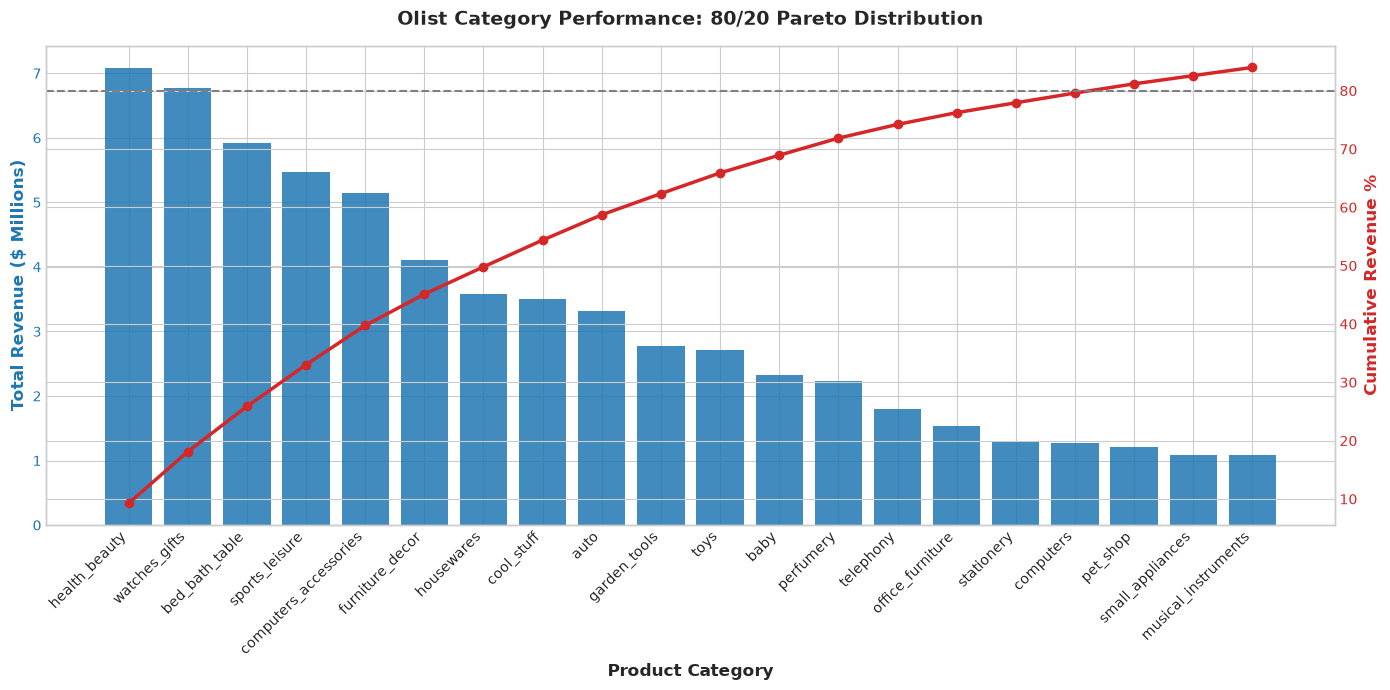

Chart successfully saved as 'pareto_chart.png'!


In [3]:
import numpy as np

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot Top 20 categories for visual clarity
df_plot = df_category.head(20).copy()

# Primary Axis: Bar plot for individual revenue
color_bar = '#1f77b4'
bars = ax1.bar(df_plot['category_name'], df_plot['total_revenue'] / 1e6, color=color_bar, alpha=0.85)
ax1.set_xlabel('Product Category', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Revenue ($ Millions)', color=color_bar, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_bar)
plt.xticks(rotation=45, ha='right')

# Secondary Axis: Cumulative percentage line
ax2 = ax1.twinx()
color_line = '#d62728'
line = ax2.plot(df_plot['category_name'], df_plot['cumulative_percentage'], color=color_line, marker='o', linewidth=2.5)
ax2.set_ylabel('Cumulative Revenue %', color=color_line, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_line)

# Add 80% Pareto Reference Line
ax2.axhline(80, color='gray', linestyle='--', linewidth=1.5, label='80% Revenue Cutoff')

plt.title('Olist Category Performance: 80/20 Pareto Distribution', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()

# Save image for Steiner's pitch deck
plt.savefig('pareto_chart.png', dpi=300)
plt.show()
print("Chart successfully saved as 'pareto_chart.png'!")

# Week 2 Integration, GCP Deployment & Analytics Polish**

## 1. Pareto Visual Chart

/tmp/ipykernel_13121/3794581864.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(df_plot['category_name'], rotation=45, ha='right')


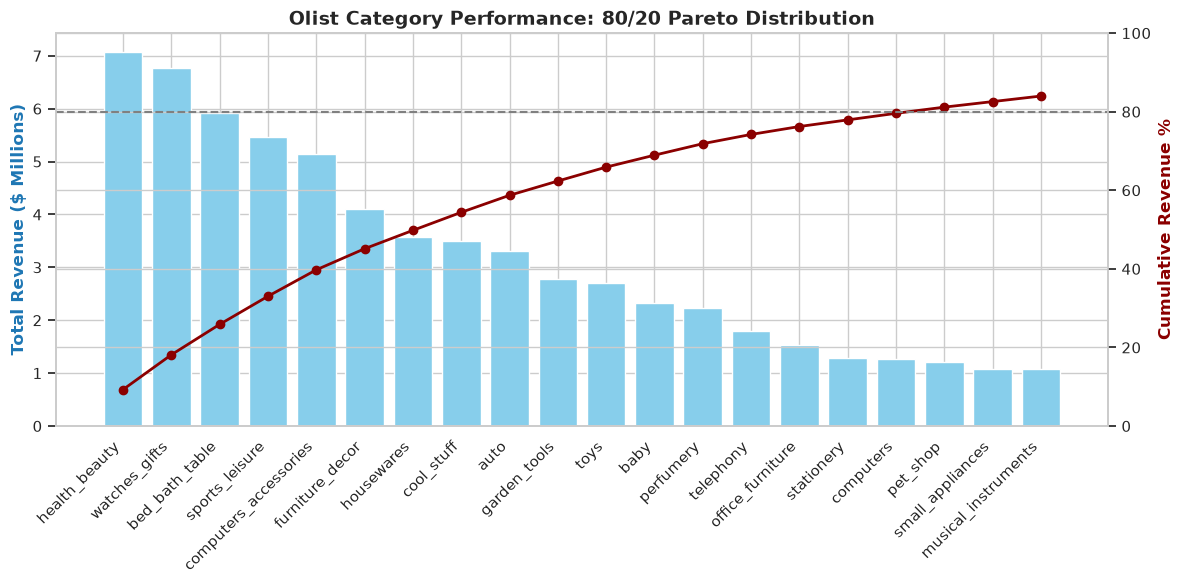

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot top 20 categories so the 80% line is crossed clearly
df_plot = df_category.head(20)

# Primary Axis: Revenue Bars
ax1.bar(df_plot['category_name'], df_plot['total_revenue'] / 1e6, color='skyblue')
ax1.set_ylabel('Total Revenue ($ Millions)', color='#1f77b4', fontweight='bold')
ax1.set_xticklabels(df_plot['category_name'], rotation=45, ha='right')

# Secondary Axis: Cumulative % Line
ax2 = ax1.twinx()
ax2.plot(df_plot['category_name'], df_plot['cumulative_percentage'], color='darkred', marker='o', linewidth=2)
ax2.set_ylabel('Cumulative Revenue %', color='darkred', fontweight='bold')
ax2.set_ylim(0, 100)  # Align scale directly to 100%

# Draw 80% cutoff line on the right axis
ax2.axhline(80, color='gray', linestyle='--', linewidth=1.5, label='80% Cutoff')

plt.title('Olist Category Performance: 80/20 Pareto Distribution', fontsize=14, fontweight='bold')
fig.tight_layout()

# Save image for Steiner's pitch deck
# plt.savefig('Revised_pareto_chart.png', dpi=300)
plt.show()
# print("Chart successfully saved as 'Revised_pareto_chart.png'!")


### Populate Presentation Slides: Draft summary slides highlighting:
Tier A Categories (Top 80% Revenue): Key drivers such as health_beauty, watches_gifts, bed_bath_table, and sports_leisure.
Inventory Strategy Takeaway: Prioritize stock retention for Tier A while streamlining or discounting Tier C (bottom 5%).

## 2.	Monthly Category Revenue Trends
To analyze monthly revenue trends and identify rising versus declining product categories over time, we first isolate the Top 5 and Bottom 5 categories based on overall historical revenue. Then, we aggregate their monthly revenue across order_purchase_timestamp to compute Month-over-Month (MoM) growth.

### 1. BigQuery SQL Query Target, Python Analysis and Trend Line Visualization
Calculate each category's total historical rank, filters for the Top 5 and Bottom 5 categories, and extracts monthly revenue along with MoM revenue dollar and percentage changes. Execute the snippet below in Jupyter Notebook to pull the data, plot the monthly revenue trajectories, and analyze rising vs. declining categories.

In [5]:
from sqlalchemy import create_engine
import pandas as pd

engine = create_engine("bigquery://ds6-module-2-olist-analytics/olist_dbt_dev")

# category_performance_monthly uses category_name_english / revenue (not
# category_name / monthly_revenue) -- aliasing here so downstream cells
# (which expect category_name / monthly_revenue) don't need to change.
# Note: this mart is already scoped to delivered orders, Jan 2017-Aug 2018,
# so the date filter a couple cells down is now redundant (dbt handles it).
trends_query = """
    WITH category_totals AS (
        SELECT
            category_name_english,
            SUM(revenue) AS total_revenue
        FROM category_performance_monthly
        GROUP BY 1
    ),
    ranked AS (
        SELECT
            category_name_english,
            RANK() OVER (ORDER BY total_revenue DESC) AS rank_desc,
            RANK() OVER (ORDER BY total_revenue ASC) AS rank_asc
        FROM category_totals
    )
    SELECT
        m.order_month,
        m.category_name_english AS category_name,
        m.revenue AS monthly_revenue,
        CASE
            WHEN r.rank_desc <= 5 THEN 'Top 5'
            WHEN r.rank_asc <= 5 THEN 'Bottom 5'
        END AS category_group
    FROM category_performance_monthly m
    JOIN ranked r ON m.category_name_english = r.category_name_english
    WHERE r.rank_desc <= 5 OR r.rank_asc <= 5
    ORDER BY m.order_month
"""

df_trends = pd.read_sql(trends_query, con=engine)
df_trends.head()


,order_month,category_name,monthly_revenue,category_group
0,2017-01-01 00:00:00+00:00,watches_gifts,46753.16,Top 5
1,2017-01-01 00:00:00+00:00,home_comfort_2,530.80,Bottom 5
2,2017-01-01 00:00:00+00:00,health_beauty,70669.87,Top 5
3,2017-01-01 00:00:00+00:00,computers_accessories,18237.07,Top 5
4,2017-01-01 00:00:00+00:00,sports_leisure,50408.06,Top 5


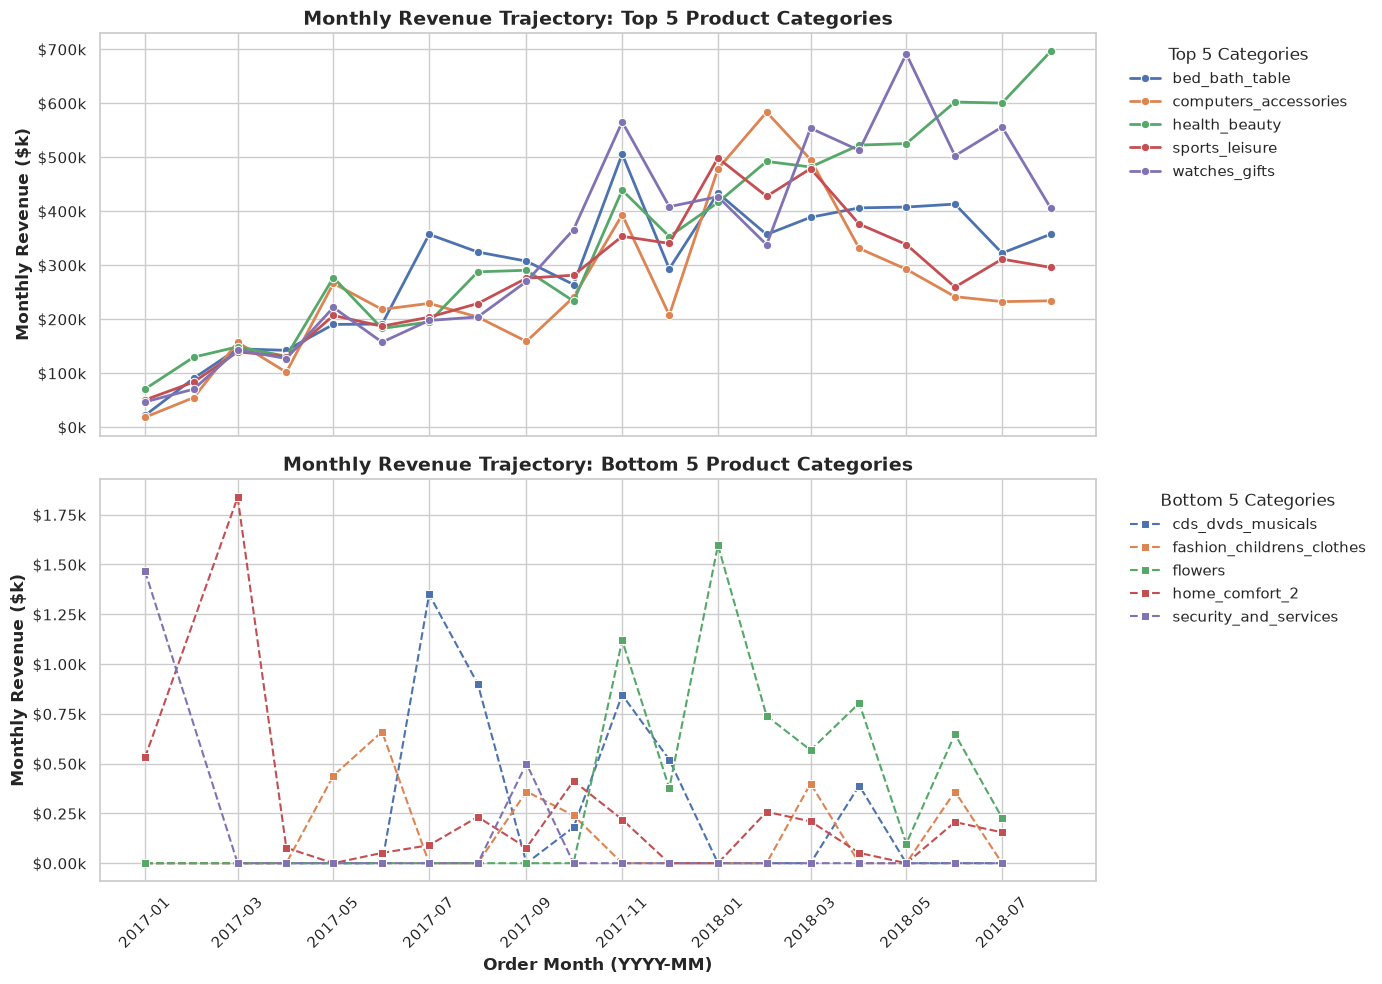

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Ensure order_month is sorted chronologically
df_trends['order_month_dt'] = pd.to_datetime(df_trends['order_month'], format='%Y-%m')
df_trends = df_trends.sort_values('order_month_dt')

# Filter out partial/incomplete boundary months
df_filtered = df_trends[
    (df_trends['order_month'] >= '2017-01') & 
    (df_trends['order_month'] <= '2018-08')
].copy()

# 2. Pivot to build complete grid (fills missing months with 0 automatically)
def prepare_continuous_df(df_sub):
    pivoted = df_sub.pivot(
        index='order_month', 
        columns='category_name', 
        values='monthly_revenue'
    ).fillna(0)
    
    # Reshape back to long format for Seaborn
    df_long = pivoted.unstack().reset_index(name='monthly_revenue')
    df_long['revenue_k'] = df_long['monthly_revenue'] / 1000
    return df_long

top_5_df = prepare_continuous_df(df_filtered[df_filtered['category_group'] == 'Top 5'])
bottom_5_df = prepare_continuous_df(df_filtered[df_filtered['category_group'] == 'Bottom 5'])

# 3. Plotting
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top 5 Plot
sns.lineplot(
    data=top_5_df, 
    x='order_month', 
    y='revenue_k', 
    hue='category_name', 
    marker='o', 
    linewidth=2, 
    ax=ax1
)
ax1.set_title('Monthly Revenue Trajectory: Top 5 Product Categories', fontsize=14, fontweight='bold')
ax1.set_ylabel('Monthly Revenue ($k)', fontweight='bold')
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}k'))
ax1.legend(title='Top 5 Categories', bbox_to_anchor=(1.02, 1), loc='upper left')

# Bottom 5 Plot
sns.lineplot(
    data=bottom_5_df, 
    x='order_month', 
    y='revenue_k', 
    hue='category_name', 
    marker='s', 
    linestyle='--', 
    linewidth=1.5, 
    ax=ax2
)
ax2.set_title('Monthly Revenue Trajectory: Bottom 5 Product Categories', fontsize=14, fontweight='bold')
ax2.set_ylabel('Monthly Revenue ($k)', fontweight='bold')
ax2.set_xlabel('Order Month (YYYY-MM)', fontweight='bold')
ax2.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.2f}k'))
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Bottom 5 Categories', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

### **Key Observations & Insights**

#### **1. Top 5 Categories (Rising vs. Declining Trajectories)**

* **Strong Rising Star (`health_beauty`):** Shows steady, sustained upward growth throughout 2017–2018, overtaking all other categories to peak near **$700k** in August 2018.
* **Holiday Season Spike (`watches_gifts`):** Experiences a major seasonal surge in **November 2017 ($560k)** and **May 2018 ($690k)**—aligning with Black Friday and Mother's Day shopping cycles—before settling.
* **Plateau / Soft Decline (`computers_accessories` & `sports_leisure`):** After peaking in late 2017 / early 2018 (~$500k–$580k), both categories trend downward through mid-2018 (~$230k–$300k).
* **Stable Performer (`bed_bath_table`):** Maintains consistent, predictable revenue trajectory between **$300k and $400k** per month during 2018.

---

#### **2. Bottom 5 Categories (Revenue Volatility & Inactivity)**

* **Extreme Sparsity:** All 5 categories generate less than **$1.85k** in any single month.
* **Intermittent Sales Spikes:** Categories like `flowers` and `cds_dvds_musicals` experience isolated spikes (e.g., `flowers` peaking near **$1.6k** in Jan 2018) followed by multi-month periods of zero sales.
* **Inactive / Dormant Category (`security_and_services`):** Generates $1.47k in Jan 2017 and **$0 in revenue for every single month thereafter** through Aug 2018.

---

### **Actionable Recommendations for Business Presentation**

1. **Capitalize on `health_beauty` Growth:** Allocate additional inventory fulfillment and marketing budget to maintain momentum in this top-performing driver.
2. **Seasonal Inventory Management:** Optimize inventory buffers for `watches_gifts` ahead of Q4 (November) and Q2 (May) spikes.
3. **Deprecate / Review Dormant Categories:** Consider deprecating or offloading listing promotions for `security_and_services` and `cds_dvds_musicals` due to prolonged idle demand.